# Libraries and data

In [1]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
# Path to the folder
%cd "/content/drive/MyDrive/Colab Notebooks"


/content/drive/MyDrive/Colab Notebooks


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns

In [27]:
# Load the data
data = pd.read_csv('Clothing.csv')
data.head()

,tsales,sales,margin,nown,nfull,npart,naux,hoursw,hourspw,inv1,inv2,ssize,start
0,750000,4411.765,41.0,1.0,1.0000,1.0000,1.5357,76,16.75596,17166.67,27177.04,170,41.0
1,1926395,4280.878,39.0,2.0,2.0000,3.0000,1.5357,192,22.49376,17166.67,27177.04,450,39.0
2,1250000,4166.667,40.0,1.0,2.0000,2.2222,1.4091,114,17.19120,292857.20,71570.55,300,40.0
3,694227,2670.104,40.0,1.0,1.0000,1.2833,1.3673,100,21.50260,22207.04,15000.00,260,40.0
4,750000,15000.000,44.0,2.0,1.9556,1.2833,1.3673,104,15.74279,22207.04,10000.00,50,44.0


In [29]:
# Variables => impact sales
# remove mutual causality bias variables
df = data[["tsales", "margin", "nown","hourspw","inv1","inv2","start"]]
df.head()


,tsales,margin,nown,hourspw,inv1,inv2,start
0,750000,41.0,1.0,16.75596,17166.67,27177.04,41.0
1,1926395,39.0,2.0,22.49376,17166.67,27177.04,39.0
2,1250000,40.0,1.0,17.19120,292857.20,71570.55,40.0
3,694227,40.0,1.0,21.50260,22207.04,15000.00,40.0
4,750000,44.0,2.0,15.74279,22207.04,10000.00,44.0


In [30]:
# Assess the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tsales   400 non-null    int64  
 1   margin   400 non-null    float64
 2   nown     400 non-null    float64
 3   hourspw  400 non-null    float64
 4   inv1     400 non-null    float64
 5   inv2     400 non-null    float64
 6   start    400 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.0 KB


Data Analysis

In [31]:
# Summary Statistics
df.describe()

,tsales,margin,nown,hourspw,inv1,inv2,start
count,4.000000e+02,400.000000,400.000000,400.000000,4.000000e+02,400.000000,400.000000
mean,8.335842e+05,38.774230,1.283796,18.955044,5.825726e+04,27829.217000,42.808462
std,5.834638e+05,5.218184,0.639773,7.343363,1.075588e+05,41501.943418,13.296070
min,5.000000e+04,16.000000,1.000000,5.707966,1.000000e+03,350.000000,16.000000
25%,4.953400e+05,37.000000,1.000000,13.541198,2.000000e+04,10000.000000,37.000000
50%,6.942270e+05,39.000000,1.000000,17.744585,2.220704e+04,22859.850000,40.000000
75%,9.768170e+05,41.000000,1.295225,24.302982,6.226923e+04,22859.850000,42.000000
max,5.000000e+06,66.000000,10.000000,43.326020,1.500000e+06,400000.000000,90.000000


<Axes: >

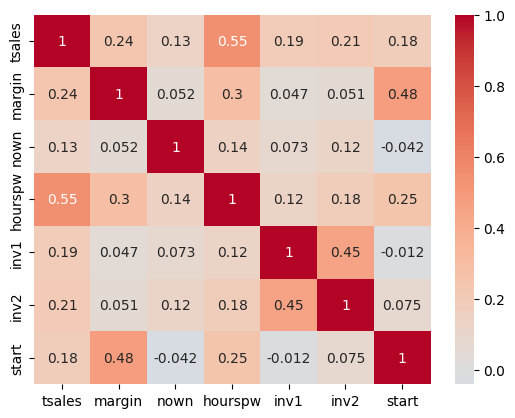

In [41]:
# Correlation matrix
sns.heatmap(df.corr(), annot=True,cmap= "coolwarm" ,center=0)

Multilinear Regression Prep

In [43]:
# Extract the X and Y
Y = df.tsales
X = df.drop(columns = 'tsales')

# Add a constant
X = sm.add_constant(X)

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 1502)

Multilinear Regression


In [45]:
# Build the regression model
model = sm.OLS(Y_train, X_train).fit()

# Print the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 tsales   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     20.95
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           1.19e-20
Time:                        16:03:38   Log-Likelihood:                -4640.8
No. Observations:                 320   AIC:                             9296.
Df Residuals:                     313   BIC:                             9322.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.096e+05   2.11e+05     -0.993      0.3

In [46]:
# Generate the predictions
predictions = model.predict(X_test)

In [47]:
# Accuracy assessment
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Calculate the RMSE, MAE and MAPE

rmse = root_mean_squared_error(Y_test, predictions)
mae = mean_absolute_error(Y_test, predictions)
mape = mean_absolute_percentage_error(Y_test, predictions)

# Display with 2 floating points
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'MAPE: {mape:.2%}')

RMSE: 460718.30
MAE: 292872.76
MAPE: 57.80%


**The predictors are not super good**
